# Notebook 2c — RF con CV por animal sin explotación
### Tuberculosis bovina

Evalúa el Random Forest usando **validación cruzada estratificada por animal**
(RepeatedStratifiedKFold) **ignorando completamente la explotación**: no se usa como
covariable del modelo ni para estructurar el CV split.

> **Pregunta de investigación:** ¿pueden los biomarcadores individuales (vitamina D, calcio,
> serología parasitaria, edad, raza) predecir el estado de TB bovina *sin ninguna información
> sobre la granja de origen*? Este escenario representa un test diagnóstico desplegable
> en granjas desconocidas, usando solo resultados de laboratorio.

**Comparar con:**
- *Notebook 2* (LOFO): generalización real a granjas nuevas.
- *Notebook 2b* (CV animal + expl): señal predictiva cuando se conoce la granja.
- *Este notebook (2c)*: límite superior del test diagnóstico en escenario sin farm-info.


## 1. Setup e importaciones

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold,
                                     LeaveOneGroupOut)
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             brier_score_loss, matthews_corrcoef, recall_score)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import shap
import tb_utils as tb

PALETTE = tb.set_plot_style()
tb.set_seeds(tb.SEED)

import os

DATA = "../BD.csv"
df = tb.clean(tb.load_raw(DATA))

d = tb.target_subset(df, "Lesiones_TB")
d = tb.drop_sparse_rows(d)          # elimina filas con >4 NaN en features del modelo

# Features: SOLO biomarcadores — sin ninguna variable de explotación
X_all = d[tb.MODEL_FEATURES].copy()
y     = d["Lesiones_TB"].astype(int).values
g     = d[tb.GROUP_COL].values   # guardado para referencia/comparación; NO usado en CV

print(f"Dataset: n={len(y)}, prevalencia={y.mean():.3f}")
print(f"Features ({len(tb.MODEL_FEATURES)}): {tb.MODEL_FEATURES}")
print(f"Línea base PR-AUC (prevalencia) = {y.mean():.3f}")
print(f"\nNota: la variable explotación (granja) se IGNORA completamente.")
print(f"CV splits cruzan granjas libremente → estimación optimista.")


drop_sparse_rows: 3 fila(s) eliminada(s) (>4 NaN en features). n restante = 103.
Dataset: n=103, prevalencia=0.612
Features (8): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'EDAD', 'PIROPLASMA', 'THEILERIA', 'ANAPLASMA', 'RAZA2']
Línea base PR-AUC (prevalencia) = 0.612

Nota: la variable explotación (granja) se IGNORA completamente.
CV splits cruzan granjas libremente → estimación optimista.


## 2. Random Forest y estrategia de validación cruzada

**CV por animal sin explotación (RepeatedStratifiedKFold, 5×10):**
- Estratificado solo por `y` (balance de clases).
- La variable explotación **no existe** en ninguna parte del pipeline.
- Dado que animales de la misma granja pueden estar simultáneamente en train y test,
  y la granja es un fuerte confundidor, esta estimación es **optimista** respecto al
  verdadero rendimiento en nuevas granjas.
- Su valor es revelar la señal máxima extraíble de los biomarcadores bajo el supuesto
  (no verificado) de independencia entre animales de distintas granjas.


In [2]:
def make_rf(n_estimators=100, min_samples_leaf=5):
    return RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=None,
        min_samples_leaf=min_samples_leaf,
        max_features="sqrt",
        class_weight="balanced",
        random_state=tb.SEED,
        n_jobs=-1,
        oob_score=True,
    )

def make_pipe_c(feature_list,n_estimators=100):
    """Pipeline sin escalado, sin explotación."""
    num_f = [f for f in feature_list if f in tb.NUM_FEATURES]
    cat_f = [f for f in feature_list if f in tb.CAT_FEATURES]
    prep  = tb.make_preprocessor(numeric=num_f, categorical=cat_f, scale=False)
    return Pipeline([("prep", prep), ("clf", make_rf(n_estimators=n_estimators))])

CV_OUTER = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)

def cv_animal_metrics_c(feature_list, X, y, cv=None, detailed=False,n_estimators=100):
    """PR-AUC y métricas con CV por animal (sin explotación)."""
    if cv is None:
        cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)
    Xs = X[list(feature_list)]
    pipe_tmpl = make_pipe_c(feature_list,n_estimators)
    rows = []
    for tr, te in cv.split(Xs, y):
        if len(np.unique(y[te])) < 2:
            continue
        pf = clone(pipe_tmpl)
        pf.fit(Xs.iloc[tr], y[tr])
        p    = pf.predict_proba(Xs.iloc[te])[:, 1]
        pred = (p >= 0.5).astype(int)
        rows.append(dict(
            prauc = average_precision_score(y[te], p),
            roc   = roc_auc_score(y[te], p),
            brier = brier_score_loss(y[te], p),
            mcc   = matthews_corrcoef(y[te], pred),
            sens  = recall_score(y[te], pred, pos_label=1, zero_division=0),
            spec  = recall_score(y[te], pred, pos_label=0, zero_division=0),
        ))
    df_r = pd.DataFrame(rows)
    if detailed:
        return df_r
    return df_r.prauc.mean(), df_r.prauc.std()

# Evaluación baseline
print("Evaluación baseline RF (todos los features de biomarcadores, CV por animal):")
base_m, base_s = cv_animal_metrics_c(tb.MODEL_FEATURES, X_all, y)
print(f"  PR-AUC = {base_m:.3f} ± {base_s:.3f}")
print(f"  Línea base (prevalencia) = {y.mean():.3f}")


Evaluación baseline RF (todos los features de biomarcadores, CV por animal):
  PR-AUC = 0.663 ± 0.074
  Línea base (prevalencia) = 0.612


## 3. Pipeline de selección de características

Mismo algoritmo que Notebooks 2 y 2b, usando **CV por animal sin explotación**:
1. Importancia de permutación sobre modelo completo (en muestra) → ranking.
2. Eliminación hacia atrás, calculando PR-AUC CV por animal en cada paso.
3. Selección: subconjunto más pequeño con PR-AUC ≥ máx − 1·DE.


Paso 1: Ajustando RF completo para ranking de importancia...
OOB Score (en muestra): 0.495

Ranking importancia de permutación (sin explotación):
                 pretty  imp_mean  imp_std
                 Calcio    0.1048   0.0186
             Vitamina D    0.0883   0.0223
            Edad (años)    0.0676   0.0233
log(1+Carga piroplasma)    0.0383   0.0074
                   Raza    0.0187   0.0051
     Anaplasma spp. (+)    0.0186   0.0080
     Theileria spp. (+)    0.0045   0.0025
         Piroplasma (+)    0.0035   0.0012


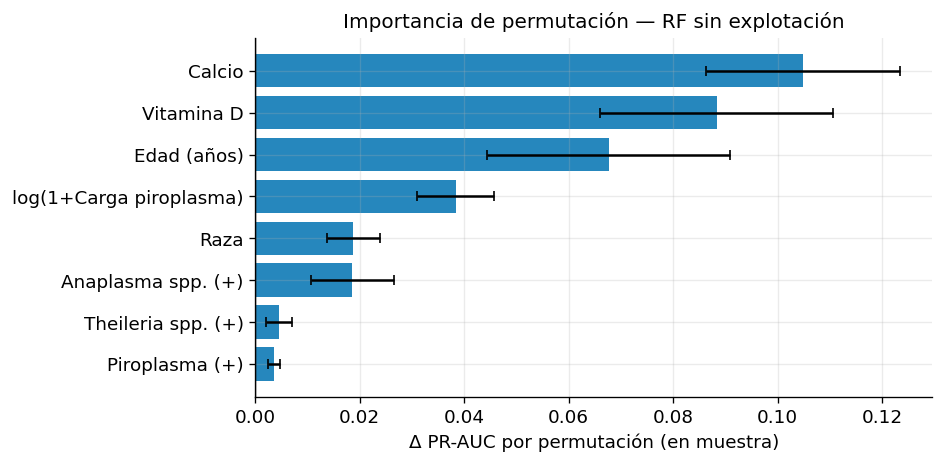

In [3]:
print("Paso 1: Ajustando RF completo para ranking de importancia...")
full_pipe = make_pipe_c(tb.MODEL_FEATURES).fit(X_all, y)
print(f"OOB Score (en muestra): {full_pipe.named_steps['clf'].oob_score_:.3f}")

pi = permutation_importance(
    full_pipe, X_all, y,
    scoring="average_precision",
    n_repeats=50,
    random_state=tb.SEED,
    n_jobs=-1,
)
imp_df = pd.DataFrame({
    "feature":  tb.MODEL_FEATURES,
    "imp_mean": pi.importances_mean,
    "imp_std":  pi.importances_std,
}).sort_values("imp_mean", ascending=False).reset_index(drop=True)
imp_df["pretty"] = imp_df.feature.map(lambda f: tb.PRETTY.get(f, f))

print("\nRanking importancia de permutación (sin explotación):")
print(imp_df[["pretty", "imp_mean", "imp_std"]].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
order = imp_df.sort_values("imp_mean")
ax.barh(order.pretty, order.imp_mean, xerr=order.imp_std, color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ PR-AUC por permutación (en muestra)")
ax.set_title("Importancia de permutación — RF sin explotación")
plt.tight_layout(); plt.savefig("figures/fig_2c_perm_importance_full.png"); plt.show()


In [4]:
CV_SEL = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=tb.SEED)
elim_order = imp_df.sort_values("imp_mean", ascending=True)["feature"].tolist()
print(f"Orden de eliminación: {elim_order}\n")
print("Paso 2: Eliminación hacia atrás (CV por animal, puede tardar 1-2 min)...\n")

current_features = tb.MODEL_FEATURES.copy()
history = []

m0, s0 = cv_animal_metrics_c(current_features, X_all, y, cv=CV_SEL)
history.append({"n": len(current_features), "features": current_features.copy(),
                "removed": "—(baseline)", "mean": m0, "std": s0})
print(f"  {len(current_features):2d} features [baseline] PR-AUC={m0:.3f}±{s0:.3f}")

for feat in elim_order:
    if feat not in current_features or len(current_features) <= 1:
        break
    test_feats = [f for f in current_features if f != feat]
    m, s = cv_animal_metrics_c(test_feats, X_all, y, cv=CV_SEL)
    history.append({"n": len(test_feats), "features": test_feats.copy(),
                    "removed": feat, "mean": m, "std": s})
    print(f"  {len(test_feats):2d} features [-{feat:20s}] PR-AUC={m:.3f}±{s:.3f}  Δ={m-m0:+.3f}")
    current_features = test_feats

hist_df = pd.DataFrame(history)


Orden de eliminación: ['PIROPLASMA', 'THEILERIA', 'ANAPLASMA', 'RAZA2', 'PIROPLASMA_Q_log', 'EDAD', 'VITAMINA_D', 'CALCIO']

Paso 2: Eliminación hacia atrás (CV por animal, puede tardar 1-2 min)...

   8 features [baseline] PR-AUC=0.676±0.073
   7 features [-PIROPLASMA          ] PR-AUC=0.702±0.078  Δ=+0.026
   6 features [-THEILERIA           ] PR-AUC=0.697±0.068  Δ=+0.021
   5 features [-ANAPLASMA           ] PR-AUC=0.714±0.070  Δ=+0.038
   4 features [-RAZA2               ] PR-AUC=0.708±0.079  Δ=+0.033
   3 features [-PIROPLASMA_Q_log    ] PR-AUC=0.740±0.057  Δ=+0.065
   2 features [-EDAD                ] PR-AUC=0.741±0.067  Δ=+0.065
   1 features [-VITAMINA_D          ] PR-AUC=0.713±0.081  Δ=+0.037


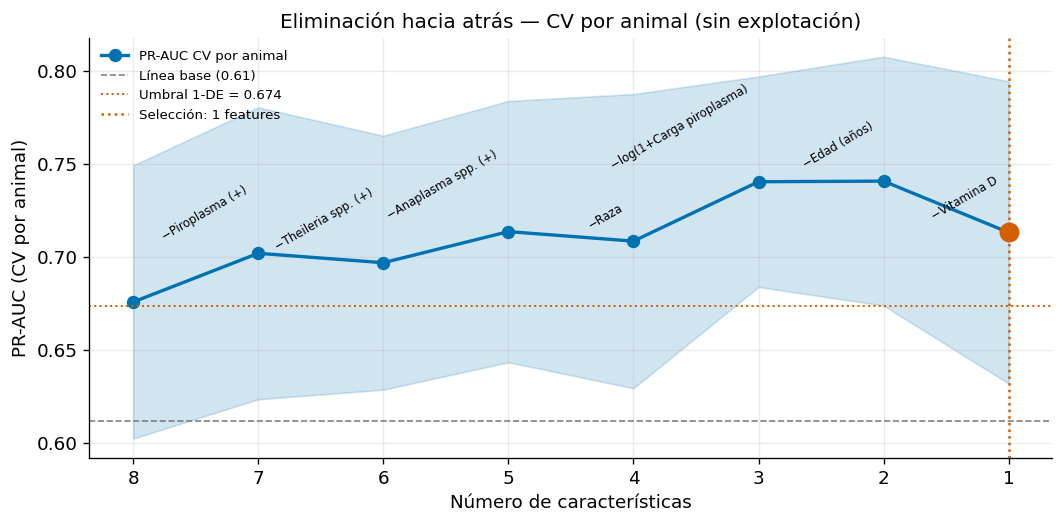


Features SELECCIONADOS (1): ['CALCIO']


In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist_df.n, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7, label="PR-AUC CV por animal")
ax.fill_between(hist_df.n,
                hist_df["mean"] - hist_df["std"],
                hist_df["mean"] + hist_df["std"], alpha=0.18, color=PALETTE[0])
ax.axhline(y.mean(), ls="--", color="grey", lw=1, label=f"Línea base ({y.mean():.2f})")

best_idx     = hist_df["mean"].idxmax()
best_mu      = hist_df["mean"].max()
best_sd      = hist_df.loc[best_idx, "std"]
threshold    = best_mu - best_sd
parsimonious = hist_df[hist_df["mean"] >= threshold].sort_values("n").iloc[0]

ax.axhline(threshold, ls=":", color=PALETTE[1], lw=1.2, label=f"Umbral 1-DE = {threshold:.3f}")
ax.axvline(parsimonious.n, color=PALETTE[1], ls=":", lw=1.5,
           label=f"Selección: {int(parsimonious.n)} features")
ax.scatter([parsimonious.n], [parsimonious["mean"]], color=PALETTE[1], s=120, zorder=5)

for _, row in hist_df.iterrows():
    label = tb.PRETTY.get(row.removed, row.removed) if row.removed != "—(baseline)" else ""
    if label:
        ax.annotate(f"−{label}", (row.n, row["mean"]),
                    textcoords="offset points", xytext=(-5, 8),
                    fontsize=7, ha="right", rotation=30)

ax.set_xlabel("Número de características"); ax.set_ylabel("PR-AUC (CV por animal)")
ax.set_title("Eliminación hacia atrás — CV por animal (sin explotación)")
ax.legend(fontsize=8); ax.invert_xaxis()
plt.tight_layout(); plt.savefig("figures/fig_2c_feature_selection_curve.png"); plt.show()

SELECTED_C = list(parsimonious.features)
print(f"\nFeatures SELECCIONADOS ({len(SELECTED_C)}): {SELECTED_C}")


In [6]:
from sklearn.metrics import accuracy_score

def _cv_accuracy(feature_list, X, y, cv):
    Xs = X[list(feature_list)]
    pipe_tmpl = make_pipe_c(feature_list)
    accs = []
    for tr, te in cv.split(Xs, y):
        if len(np.unique(y[te])) < 2:
            continue
        pf = clone(pipe_tmpl)
        pf.fit(Xs.iloc[tr], y[tr])
        accs.append(accuracy_score(y[te], pf.predict(Xs.iloc[te])))
    return np.mean(accs), np.std(accs)

print("Calculando accuracy para cada subconjunto de hist_df (≈1 min)...")
acc_means, acc_stds = [], []
for _, row in hist_df.iterrows():
    m, s = _cv_accuracy(row["features"], X_all, y, CV_SEL)
    acc_means.append(m)
    acc_stds.append(s)
    print(f"  {int(row.n):2d} features [-{row['removed']:20s}] Acc={m:.3f}±{s:.3f}")

hist_df = hist_df.assign(acc_mean=acc_means, acc_std=acc_stds)
print("\nhist_df actualizado con columnas acc_mean / acc_std.")


Calculando accuracy para cada subconjunto de hist_df (≈1 min)...
   8 features [-—(baseline)         ] Acc=0.521±0.111
   7 features [-PIROPLASMA          ] Acc=0.530±0.094
   6 features [-THEILERIA           ] Acc=0.527±0.078
   5 features [-ANAPLASMA           ] Acc=0.553±0.086
   4 features [-RAZA2               ] Acc=0.530±0.101
   3 features [-PIROPLASMA_Q_log    ] Acc=0.537±0.080
   2 features [-EDAD                ] Acc=0.567±0.083
   1 features [-VITAMINA_D          ] Acc=0.518±0.073

hist_df actualizado con columnas acc_mean / acc_std.


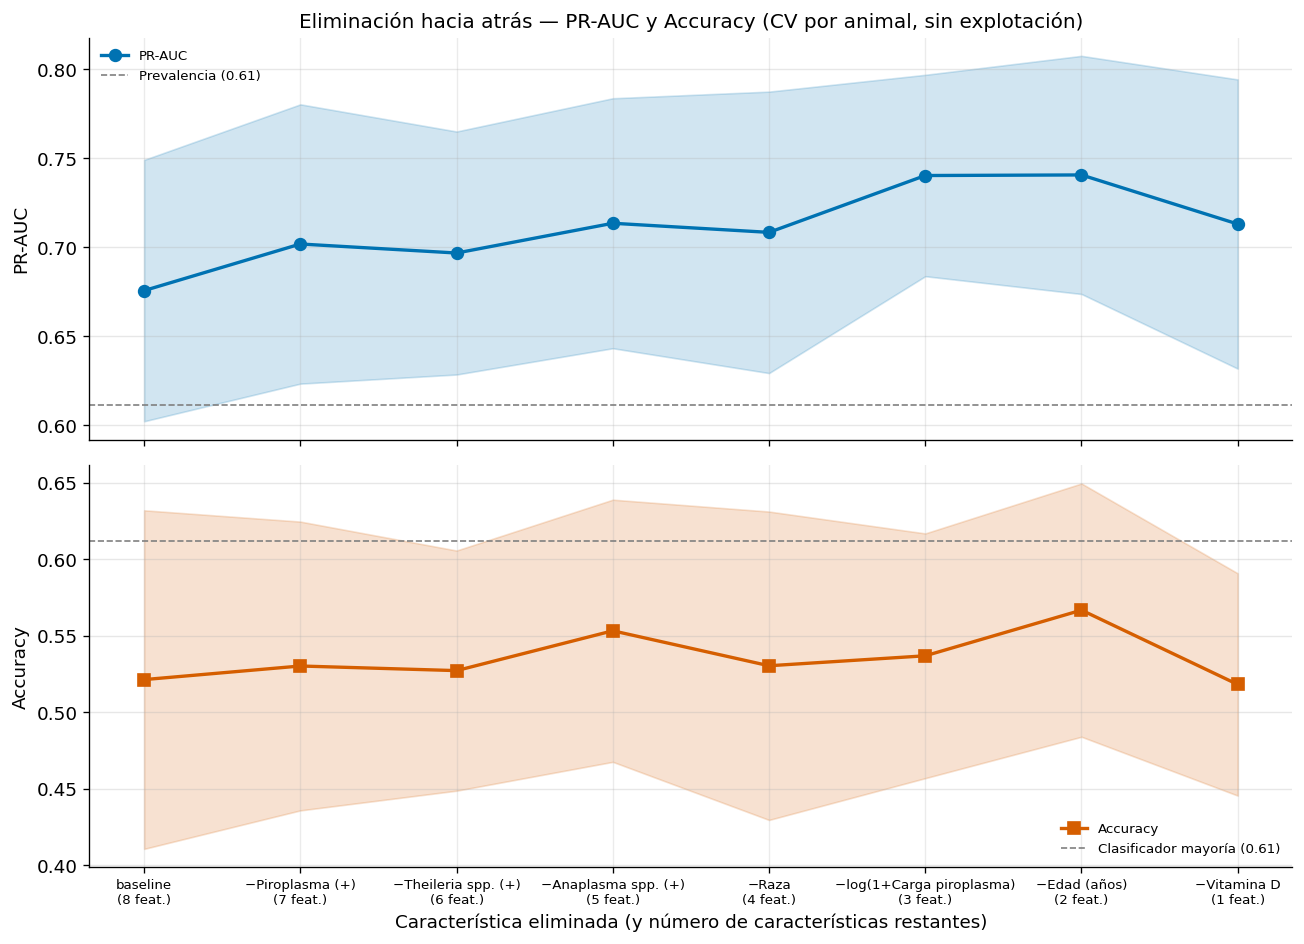

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

x      = np.arange(len(hist_df))
labels = []
for _, row in hist_df.iterrows():
    if row["removed"] == "—(baseline)":
        lbl = f"baseline\n({int(row.n)} feat.)"
    else:
        pretty = tb.PRETTY.get(row["removed"], row["removed"])
        lbl = f"−{pretty}\n({int(row.n)} feat.)"
    labels.append(lbl)

# --- PR-AUC ---
ax1 = axes[0]
ax1.plot(x, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7, label="PR-AUC")
ax1.fill_between(x,
                 hist_df["mean"] - hist_df["std"],
                 hist_df["mean"] + hist_df["std"],
                 alpha=0.18, color=PALETTE[0])
ax1.axhline(y.mean(), ls="--", color="grey", lw=1, label=f"Prevalencia ({y.mean():.2f})")
ax1.set_ylabel("PR-AUC")
ax1.legend(fontsize=8)
ax1.set_title("Eliminación hacia atrás — PR-AUC y Accuracy (CV por animal, sin explotación)")
ax1.grid(axis="y", alpha=0.3)

# --- Accuracy ---
ax2 = axes[1]
majority_cls = max(y.mean(), 1 - y.mean())
ax2.plot(x, hist_df["acc_mean"], "s-", color=PALETTE[1], lw=2, ms=7, label="Accuracy")
ax2.fill_between(x,
                 hist_df["acc_mean"] - hist_df["acc_std"],
                 hist_df["acc_mean"] + hist_df["acc_std"],
                 alpha=0.18, color=PALETTE[1])
ax2.axhline(majority_cls, ls="--", color="grey", lw=1,
            label=f"Clasificador mayoría ({majority_cls:.2f})")
ax2.set_ylabel("Accuracy")
ax2.legend(fontsize=8)
ax2.grid(axis="y", alpha=0.3)

ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=8, ha="center")
ax2.set_xlabel("Característica eliminada (y número de características restantes)")

plt.tight_layout()
plt.savefig("figures/fig_2c_feature_selection_metrics.png", bbox_inches="tight")
plt.show()


## 4. Evaluación del modelo final (CV por animal, 5×10)

Features (3): ['VITAMINA_D', 'CALCIO', 'EDAD']

Métricas CV por animal (5×10, sin explotación):
  PR-AUC = 0.731 ± 0.074   (línea base = 0.612)
  ROC    = 0.570   ± 0.104
  Brier  = 0.244  ± 0.022
  MCC    = 0.072   ± 0.168
  Sens   = 0.64   ± 0.13
  Spec   = 0.43   ± 0.16


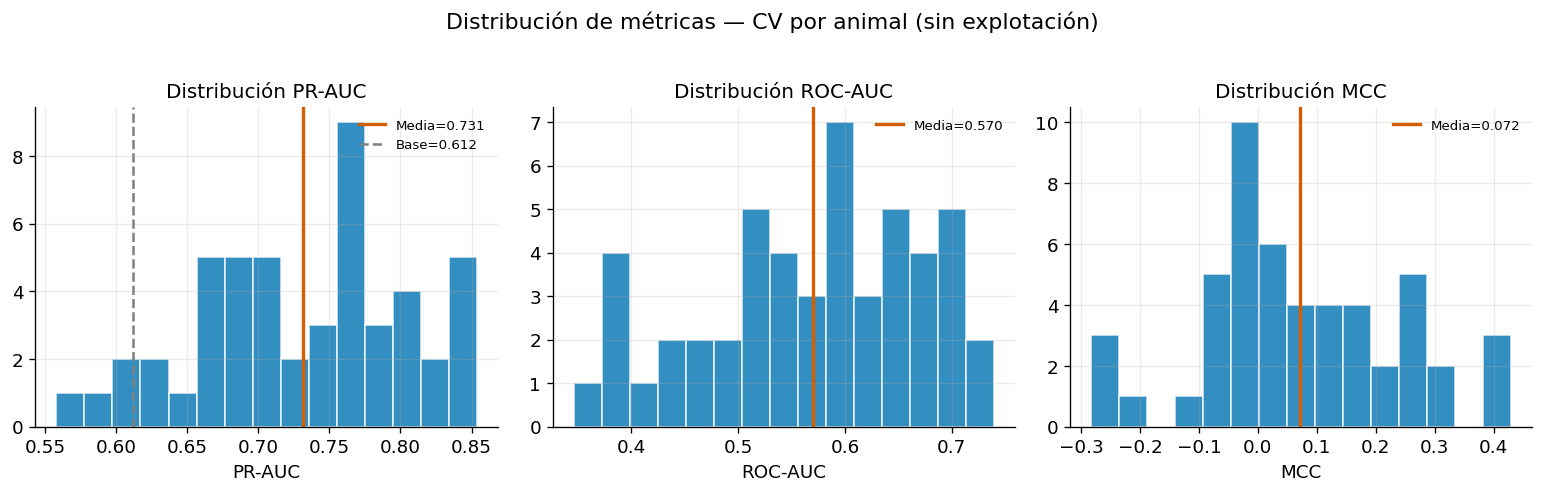

In [8]:
#Let's select the three top features
SELECTED_C = ["VITAMINA_D","CALCIO","EDAD"]

Xs = X_all[SELECTED_C].copy()
print(f"Features ({len(SELECTED_C)}): {SELECTED_C}\n")

detailed_df = cv_animal_metrics_c(SELECTED_C, X_all, y, cv=CV_OUTER, detailed=True,n_estimators = 700)
m = detailed_df.mean(); s = detailed_df.std()

print("Métricas CV por animal (5×10, sin explotación):")
print(f"  PR-AUC = {m.prauc:.3f} ± {s.prauc:.3f}   (línea base = {y.mean():.3f})")
print(f"  ROC    = {m.roc:.3f}   ± {s.roc:.3f}")
print(f"  Brier  = {m.brier:.3f}  ± {s.brier:.3f}")
print(f"  MCC    = {m.mcc:.3f}   ± {s.mcc:.3f}")
print(f"  Sens   = {m.sens:.2f}   ± {s.sens:.2f}")
print(f"  Spec   = {m.spec:.2f}   ± {s.spec:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes, ["prauc", "roc", "mcc"], ["PR-AUC", "ROC-AUC", "MCC"]):
    ax.hist(detailed_df[col].dropna(), bins=15, color=PALETTE[0], alpha=0.8, edgecolor="white")
    ax.axvline(detailed_df[col].mean(), color=PALETTE[1], lw=2,
               label=f"Media={detailed_df[col].mean():.3f}")
    if col == "prauc":
        ax.axvline(y.mean(), color="grey", ls="--", lw=1.5, label=f"Base={y.mean():.3f}")
    ax.set_xlabel(title); ax.set_title(f"Distribución {title}"); ax.legend(fontsize=8)
plt.suptitle("Distribución de métricas — CV por animal (sin explotación)", y=1.02)
plt.tight_layout(); plt.savefig("figures/fig_2c_metrics_dist.png", bbox_inches="tight"); plt.show()


## 5. Interpretabilidad global — SHAP

Este análisis muestra la importancia de los biomarcadores **en ausencia de información
de granja**. Cualquier señal detectada aquí es potencialmente transferible a nuevas granjas
(si el modelo generalizara bien, lo cual debe verificarse con LOFO — Notebook 2).


In [9]:
FINAL_C = make_pipe_c(SELECTED_C, n_estimators=500).fit(Xs, y)
print(f"OOB Score (en muestra): {FINAL_C.named_steps['clf'].oob_score_:.3f}")

prep_c  = FINAL_C.named_steps["prep"]
clf_c   = FINAL_C.named_steps["clf"]
Xt_c    = prep_c.transform(Xs)
names_c = list(prep_c.get_feature_names_out())

explainer_c = shap.TreeExplainer(clf_c)
shap_vals_c = explainer_c.shap_values(Xt_c)

# SHAP antiguo → lista [clase0, clase1]; SHAP nuevo → array 3D (n, features, clases)
if isinstance(shap_vals_c, list):
    sv_c = shap_vals_c[1]
elif np.asarray(shap_vals_c).ndim == 3:
    sv_c = np.asarray(shap_vals_c)[:, :, 1]
else:
    sv_c = np.asarray(shap_vals_c)

# Valor base (expected value) para clase positiva
exp_val_c = (float(explainer_c.expected_value[1])
             if isinstance(explainer_c.expected_value, (list, np.ndarray))
             else float(explainer_c.expected_value))

print(f"Features tras preprocesamiento : {names_c}")
print(f"SHAP values shape              : {sv_c.shape}")
print(f"Expected value (clase +)       : {exp_val_c:.4f}")


OOB Score (en muestra): 0.524
Features tras preprocesamiento : ['VITAMINA_D', 'CALCIO', 'EDAD']
SHAP values shape              : (103, 3)
Expected value (clase +)       : 0.5045


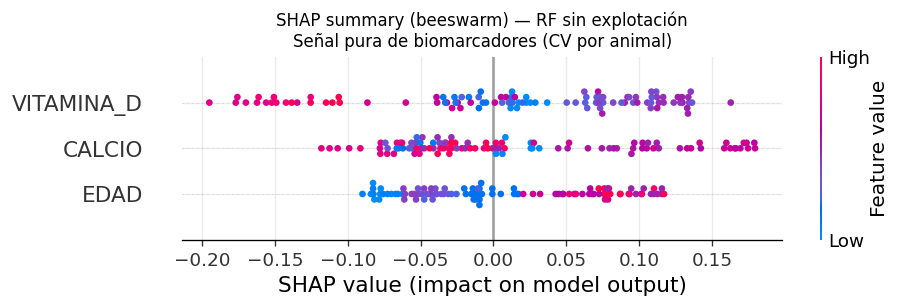

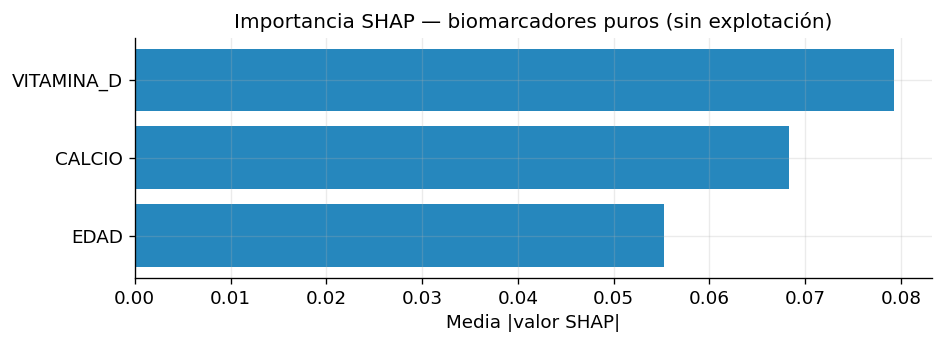

In [10]:
plt.figure(figsize=(9, max(4, 0.5 * len(names_c))))
shap.summary_plot(sv_c, Xt_c, feature_names=names_c, show=False, max_display=len(names_c))
plt.title("SHAP summary (beeswarm) — RF sin explotación\n"
          "Señal pura de biomarcadores (CV por animal)", fontsize=10)
plt.tight_layout(); plt.savefig("figures/fig_2c_shap_summary.png", bbox_inches="tight"); plt.show()

# Importancia media |SHAP|
mean_abs_c = np.abs(sv_c).mean(0)
si_c = pd.DataFrame({"feature": names_c, "mean_abs": mean_abs_c}).sort_values("mean_abs")
fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(names_c))))
ax.barh(si_c.feature, si_c.mean_abs, color=PALETTE[0], alpha=0.85)
ax.set_xlabel("Media |valor SHAP|")
ax.set_title("Importancia SHAP — biomarcadores puros (sin explotación)")
plt.tight_layout(); plt.savefig("figures/fig_2c_shap_importance.png"); plt.show()


In [11]:
# Force plot global: todos los animales ordenados por probabilidad predicha
shap.initjs()

# Ordenar por probabilidad predicha para que el plot sea más legible
order = np.argsort(FINAL_C.predict_proba(Xs)[:, 1])
fp = shap.force_plot(
    exp_val_c,
    sv_c[order, :],
    Xt_c[order, :] if hasattr(Xt_c, '__getitem__') else Xt_c[order],
    feature_names=names_c,
)
shap.save_html("figures/fig_2c_shap_force_plot_global.html", fp)
display(fp)


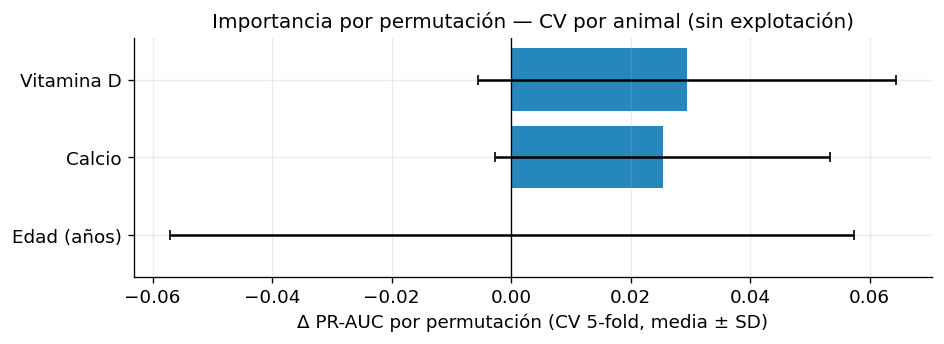

Estabilidad Spearman entre folds: -0.200


In [12]:
# Importancia por permutación — estabilidad
imp_runs_c = []
cv_stab = StratifiedKFold(n_splits=5, shuffle=True, random_state=tb.SEED)
for tr, te in cv_stab.split(Xs, y):
    if len(np.unique(y[te])) < 2: continue
    pf = clone(make_pipe_c(SELECTED_C)).fit(Xs.iloc[tr], y[tr])
    pi_f = permutation_importance(pf, Xs.iloc[te], y[te],
                                  scoring="average_precision", n_repeats=20,
                                  random_state=tb.SEED)
    imp_runs_c.append(pd.Series(pi_f.importances_mean, index=SELECTED_C))

imp_mat_c = pd.concat(imp_runs_c, axis=1)
imp_ord_c = imp_mat_c.mean(axis=1).sort_values().index

from scipy.stats import spearmanr
R = imp_mat_c.fillna(0)
cors = [spearmanr(R.iloc[:,i], R.iloc[:,j]).correlation
        for i in range(R.shape[1]) for j in range(i+1, R.shape[1])]

fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(SELECTED_C))))
ax.barh([tb.PRETTY.get(f, f) for f in imp_ord_c],
        imp_mat_c.mean(axis=1)[imp_ord_c],
        xerr=imp_mat_c.std(axis=1)[imp_ord_c],
        color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ PR-AUC por permutación (CV 5-fold, media ± SD)")
ax.set_title("Importancia por permutación — CV por animal (sin explotación)")
plt.tight_layout(); plt.savefig("figures/fig_2c_perm_importance_cv.png"); plt.show()
print(f"Estabilidad Spearman entre folds: {np.nanmean(cors):.3f}")


## 6. Partial Dependence Plots + ICE

Features continuas para PDP/ICE: ['VITAMINA_D', 'CALCIO', 'EDAD']


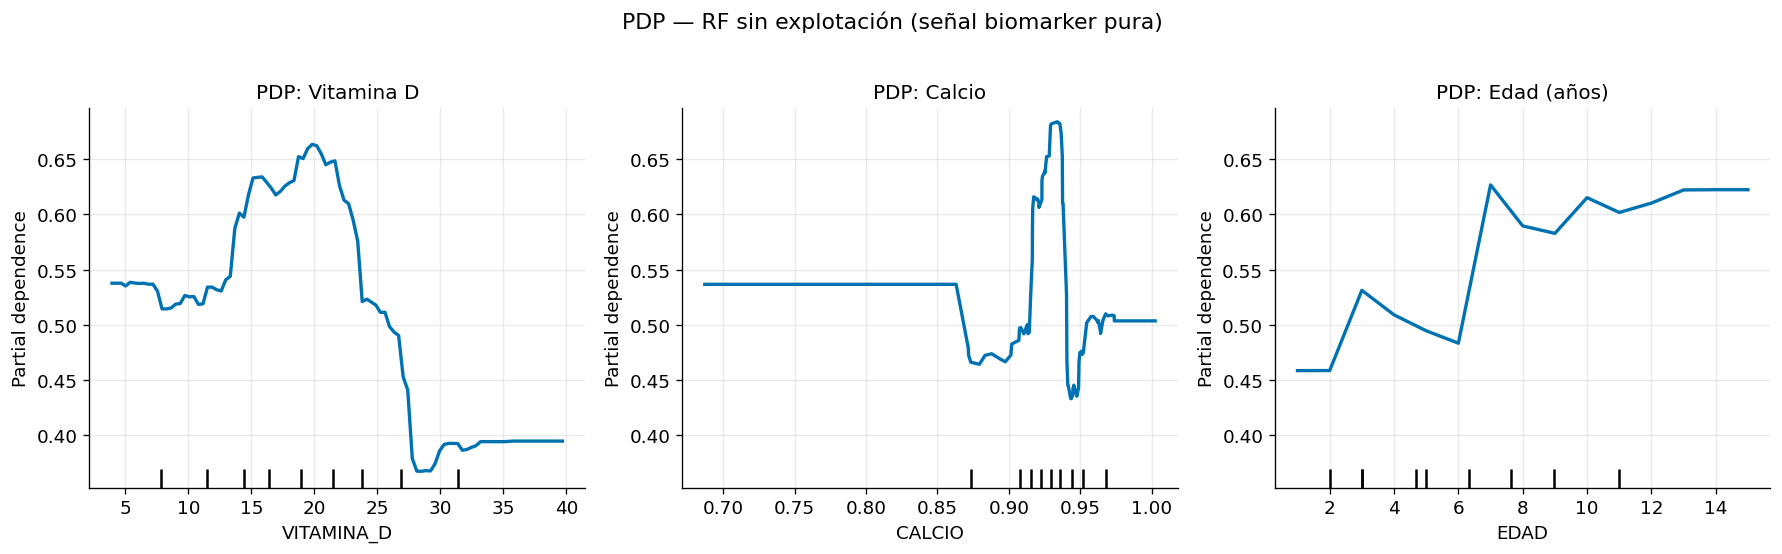

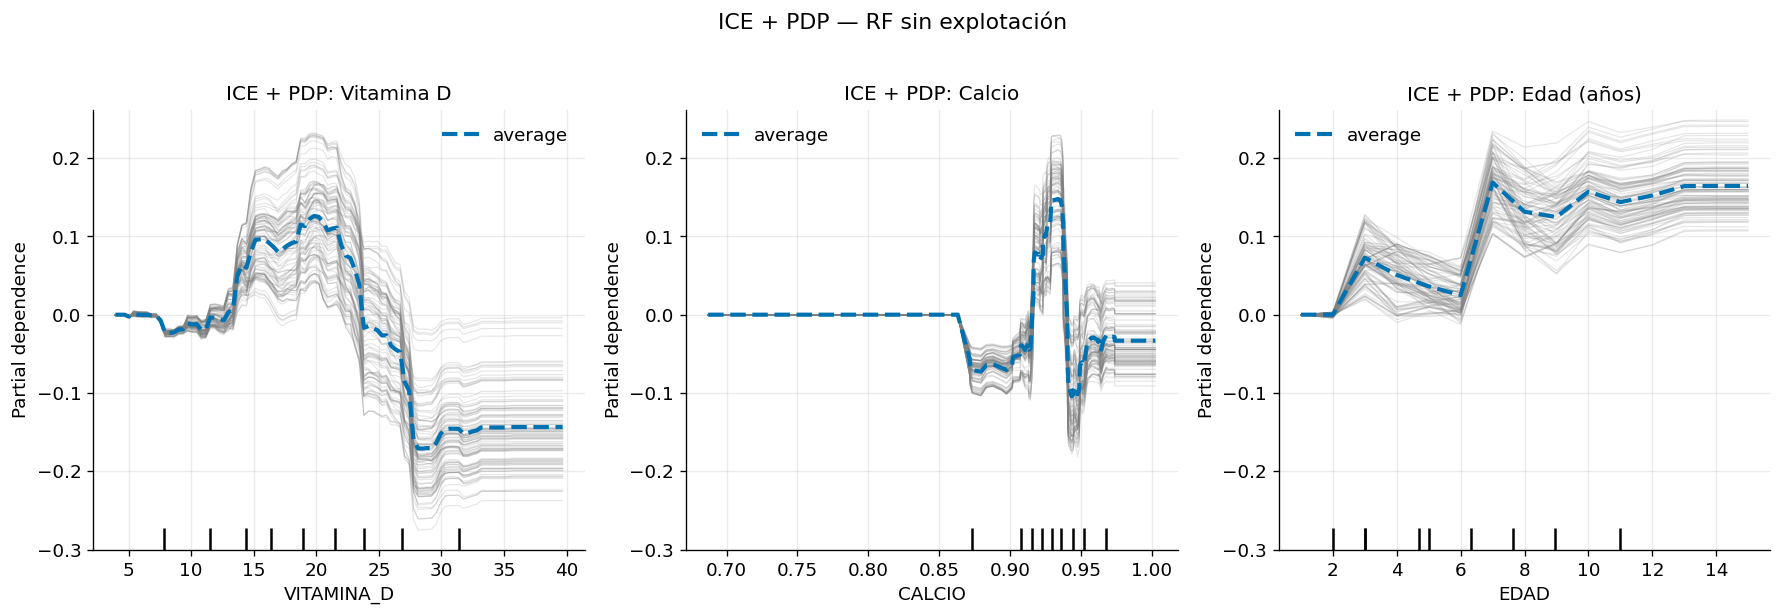

In [13]:
CONT_C = [f for f in SELECTED_C if f in tb.NUM_FEATURES and Xs[f].nunique() > 5]
if not CONT_C:
    CONT_C = [f for f in SELECTED_C if f in tb.NUM_FEATURES]

print(f"Features continuas para PDP/ICE: {CONT_C}")
if CONT_C:
    n_c = len(CONT_C)
    # PDP
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4.5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_C, Xs, CONT_C, kind="average",
        ax=axes, line_kw={"color": PALETTE[0], "lw": 2})
    for ax, f in zip(axes, CONT_C):
        ax.set_title(f"PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle("PDP — RF sin explotación (señal biomarker pura)", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_2c_pdp.png", bbox_inches="tight"); plt.show()

    # ICE + PDP
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_C, Xs, CONT_C, kind="both",
        ax=axes,
        ice_lines_kw={"color": "grey", "alpha": 0.2, "lw": 0.7},
        pd_line_kw={"color": PALETTE[0], "lw": 2.5},
        centered=True)
    for ax, f in zip(axes, CONT_C):
        ax.set_title(f"ICE + PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle("ICE + PDP — RF sin explotación", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_2c_ice.png", bbox_inches="tight"); plt.show()


## 7. Accumulated Local Effects (ALE)

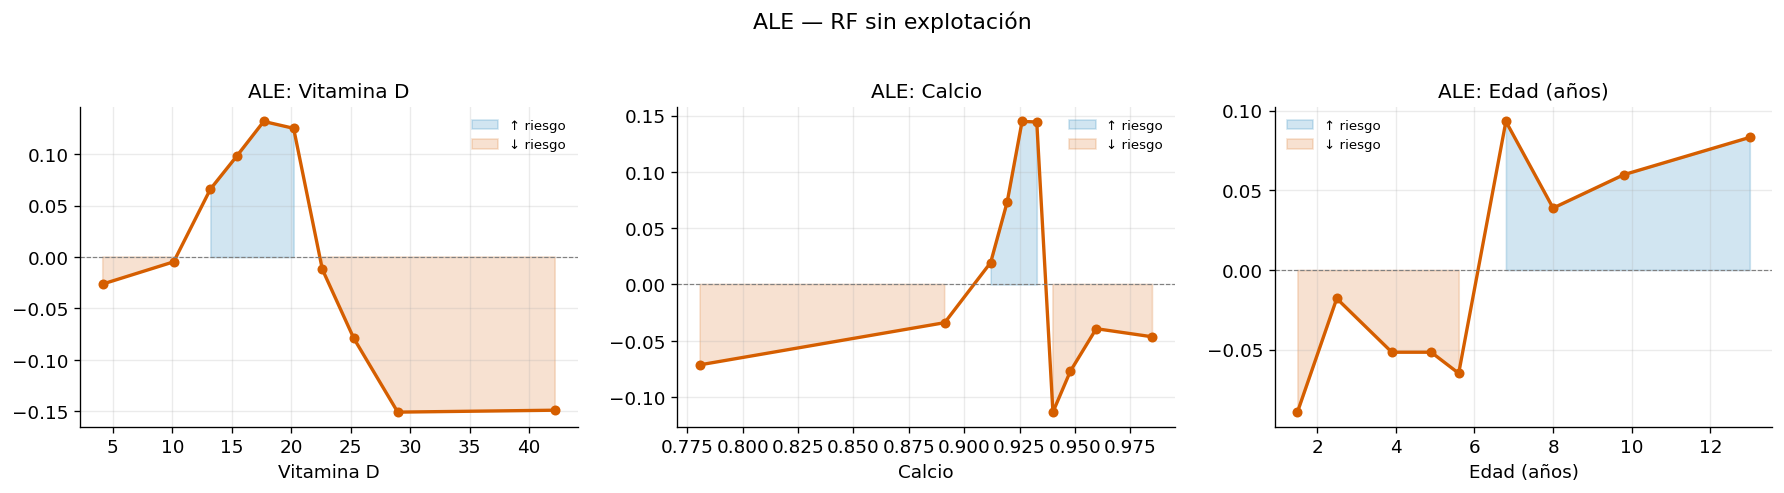

In [14]:
def ale_1d(model, X, feat, bins=10):
    x = X[feat].dropna().values
    q = np.quantile(x, np.linspace(0, 1, bins + 1)); q = np.unique(q)
    if len(q) < 3: return np.array([]), np.array([])
    eff, Xc = [], X.copy()
    for i in range(len(q) - 1):
        mask = (X[feat] >= q[i]) & (X[feat] <= q[i + 1])
        if mask.sum() == 0: eff.append(0.0); continue
        lo = Xc.loc[mask].copy(); lo[feat] = q[i]
        hi = Xc.loc[mask].copy(); hi[feat] = q[i + 1]
        eff.append((model.predict_proba(hi)[:, 1] - model.predict_proba(lo)[:, 1]).mean())
    ale = np.cumsum(eff); ale -= ale.mean()
    return (q[:-1] + q[1:]) / 2, ale

if CONT_C:
    n_c = len(CONT_C)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_C):
        cx, ale = ale_1d(FINAL_C, Xs, feat)
        if len(cx) == 0: ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}\n(insuf.)"); continue
        ax.plot(cx, ale, "o-", color=PALETTE[1], lw=2, ms=5)
        ax.axhline(0, color="grey", lw=0.7, ls="--")
        ax.fill_between(cx, 0, ale, where=(ale > 0), alpha=0.18, color=PALETTE[0], label="↑ riesgo")
        ax.fill_between(cx, 0, ale, where=(ale < 0), alpha=0.18, color=PALETTE[1], label="↓ riesgo")
        ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}")
        ax.set_xlabel(tb.PRETTY.get(feat,feat)); ax.legend(fontsize=8)
    plt.suptitle("ALE — RF sin explotación", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_2c_ale.png", bbox_inches="tight"); plt.show()


## 8. SHAP waterfall — interpretabilidad local

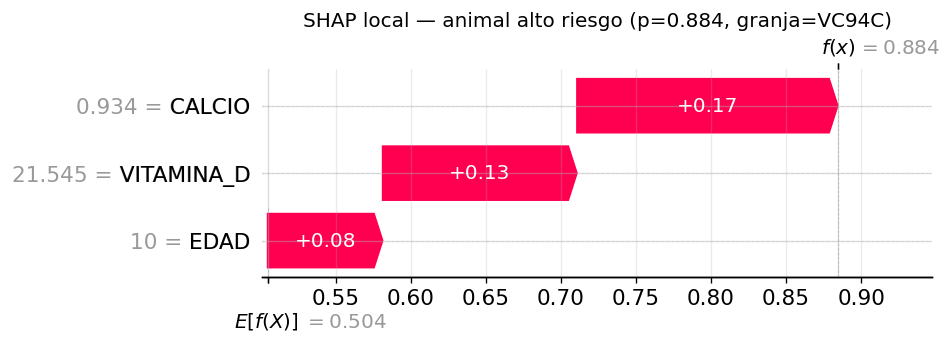

Animal 64: p=0.884, clase real=1, granja (referencia)=VC94C


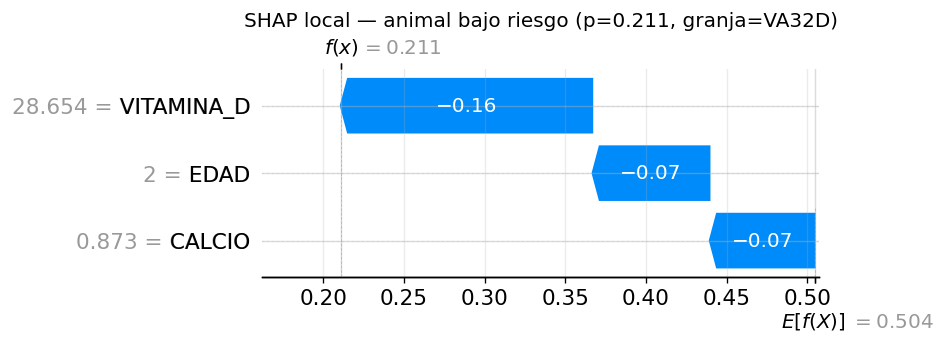

Animal 81: p=0.211, clase real=0, granja (referencia)=VA32D


In [15]:
p_all_c = FINAL_C.predict_proba(Xs)[:, 1]
idx_pos  = int(np.argmax(p_all_c))
idx_neg  = int(np.argmin(p_all_c))

# exp_val_c ya está definido en la celda SHAP de arriba
shap_exp_c = shap.Explanation(values=sv_c, base_values=exp_val_c,
                               data=Xt_c, feature_names=names_c)

for tag, idx in [("alto_riesgo", idx_pos), ("bajo_riesgo", idx_neg)]:
    farm_ref = g[idx]
    fig, _ = plt.subplots(figsize=(9, 4))
    shap.plots.waterfall(shap_exp_c[idx], max_display=len(names_c), show=False)
    plt.title(f"SHAP local — animal {tag.replace('_',' ')} (p={p_all_c[idx]:.3f}, granja={farm_ref})")
    plt.tight_layout()
    plt.savefig(f"figures/fig_2c_waterfall_{tag}.png", bbox_inches="tight"); plt.show()
    print(f"Animal {idx}: p={p_all_c[idx]:.3f}, clase real={y[idx]}, granja (referencia)={farm_ref}")


## 9. Contrafactuales

In [16]:
def find_cf(model, row_dict, feat, lo, hi, target_cls, n=500):
    for v in np.linspace(lo, hi, n):
        r = dict(row_dict); r[feat] = v
        if int(model.predict(pd.DataFrame([r]))[0]) == target_cls:
            return v
    return None

high_row = Xs.iloc[idx_pos].copy()
low_row  = Xs.iloc[idx_neg].copy()

print("=" * 60)
print("CONTRAFACTUALES — solo con biomarcadores")
print("=" * 60)
for tag, row, target_cls in [("ALTO riesgo", high_row, 0), ("BAJO riesgo", low_row, 1)]:
    pred = int(FINAL_C.predict(pd.DataFrame([row]))[0])
    p    = FINAL_C.predict_proba(pd.DataFrame([row]))[0, 1]
    print(f"\nAnimal {tag} (predicha={pred}, p={p:.3f}), objetivo → clase {target_cls}")
    for feat in CONT_C:
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        cf = find_cf(FINAL_C, row.to_dict(), feat, lo_v, hi_v, target_cls)
        cur = row[feat]
        if cf is not None:
            print(f"  {tb.PRETTY.get(feat,feat):30s}: actual={cur:.2f} → cf={cf:.2f} (Δ={cf-cur:+.2f})")
        else:
            print(f"  {tb.PRETTY.get(feat,feat):30s}: actual={cur:.2f} → no alcanzable")


CONTRAFACTUALES — solo con biomarcadores

Animal ALTO riesgo (predicha=1, p=0.884), objetivo → clase 0
  Vitamina D                    : actual=21.55 → no alcanzable
  Calcio                        : actual=0.93 → no alcanzable
  Edad (años)                   : actual=10.00 → no alcanzable

Animal BAJO riesgo (predicha=0, p=0.211), objetivo → clase 1
  Vitamina D                    : actual=28.65 → cf=19.37 (Δ=-9.28)
  Calcio                        : actual=0.87 → no alcanzable
  Edad (años)                   : actual=2.00 → no alcanzable


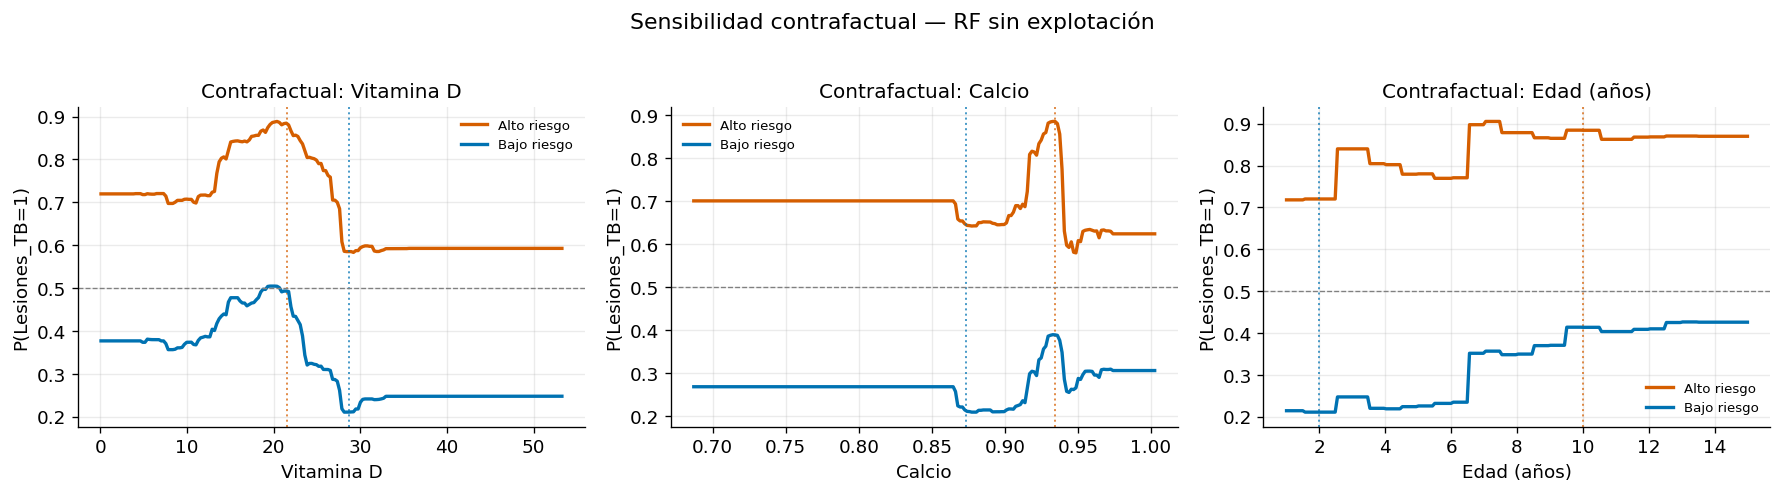

In [17]:
if CONT_C:
    n_c = len(CONT_C)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_C):
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        grid = np.linspace(lo_v, hi_v, 200)
        for tag, row, color in [("Alto riesgo", high_row, PALETTE[1]), ("Bajo riesgo", low_row, PALETTE[0])]:
            probs = [FINAL_C.predict_proba(pd.DataFrame([{**row.to_dict(), feat: v}]))[0, 1] for v in grid]
            ax.plot(grid, probs, color=color, lw=2, label=tag)
            ax.axvline(row[feat], color=color, ls=":", lw=1.2, alpha=0.7)
        ax.axhline(0.5, color="grey", ls="--", lw=0.8)
        ax.set_xlabel(tb.PRETTY.get(feat, feat)); ax.set_ylabel("P(Lesiones_TB=1)")
        ax.set_title(f"Contrafactual: {tb.PRETTY.get(feat,feat)}"); ax.legend(fontsize=8)
    plt.suptitle("Sensibilidad contrafactual — RF sin explotación", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_2c_cf_curves.png", bbox_inches="tight"); plt.show()


## 10. Síntesis y triangulación de los tres análisis

### Tabla comparativa (rellenar con resultados de los tres notebooks)

| Métrica | Nb 2 — LOFO | Nb 2b — CV + expl | **Nb 2c — CV sin expl** |
|---|---|---|---|
| PR-AUC | — | — | **—** |
| ROC-AUC | — | — | **—** |
| MCC | — | — | **—** |
| CV strategy | Leave-One-Farm-Out | RepeatedSKFold + EXPL | **RepeatedSKFold puro** |
| Expl como feature | No | Sí | **No** |
| Expl en CV split | Sí (LOFO) | No | **No** |

### Guía de interpretación

- **Si PR-AUC(2c) >> PR-AUC(2):** la señal existe en los datos pero no generaliza a nuevas
  granjas → la granja confunde fuertemente (los animales de la misma granja son similares
  en marcadores, no necesariamente por TB).

- **Si PR-AUC(2b) >> PR-AUC(2c):** añadir la explotación como feature mejora la predicción
  dentro de las granjas conocidas → hay efectos de granja explotables, pero no exportables.

- **Si PR-AUC(2c) ≈ PR-AUC(2b) y ambos >> PR-AUC(2):** los biomarcadores tienen señal real
  per se (no mediada por la granja), pero la señal no es estable entre granjas (quizás por
  diferencias en manejo, alimentación o prevalencia).

- **Si PR-AUC(2c) ≈ PR-AUC(2) ≈ prevalencia:** no hay señal predictiva robusta en los
  biomarcadores disponibles para este outcome en este dataset. El estudio tiene valor de
  generación de hipótesis, no de validación diagnóstica.

### Implicaciones clínicas
Los contrafactuales de biomarcadores en este notebook representan la palanca de intervención
más directamente clínica: son cambios en marcadores medibles sin información de granja.
Si estos contrafactuales son alcanzables en el rango observado, sugieren posibles umbrales
diagnósticos o de intervención a validar en estudios futuros.
